In [2]:
import os
from pathlib import Path

USE_KAGGLE_DOWNLOAD = True
LOCAL_DATASET_ROOT = None  # Example: "/Users/you/Downloads/food-101/food-101"

if LOCAL_DATASET_ROOT is not None:
    base_path = Path(LOCAL_DATASET_ROOT).expanduser().resolve()
else:
    if not USE_KAGGLE_DOWNLOAD:
        raise ValueError("Set LOCAL_DATASET_ROOT or enable USE_KAGGLE_DOWNLOAD.")

    import kagglehub
    path = kagglehub.dataset_download("dansbecker/food-101")
    base_path = Path(path) / "food-101" / "food-101"

print("Using dataset:", base_path)


Using dataset: C:\Users\yueya\.cache\kagglehub\datasets\dansbecker\food-101\versions\1\food-101\food-101


In [3]:
print(os.listdir(base_path))


['.DS_Store', 'images', 'license_agreement.txt', 'meta', 'README.txt']


In [4]:
from torchvision import datasets, transforms

data_dir = base_path / "images"

preview_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

preview_dataset = datasets.ImageFolder(str(data_dir), transform=preview_transform)

print(len(preview_dataset))
print(preview_dataset.classes[:5])


101000
['apple_pie', 'baby_back_ribs', 'baklava', 'beef_carpaccio', 'beef_tartare']


apple_pie


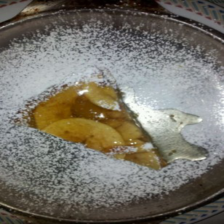

apple_pie


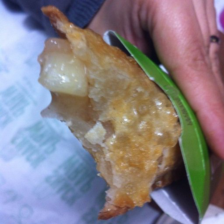

apple_pie


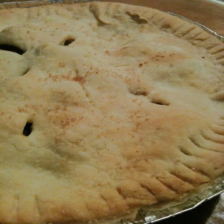

apple_pie


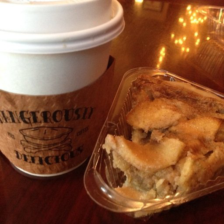

apple_pie


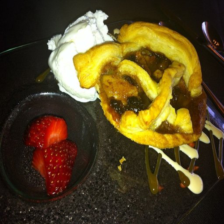

In [5]:
from IPython.display import display
from torchvision.transforms.functional import to_pil_image

for i in range(5):
    img, label = preview_dataset[i]
    img = to_pil_image(img)

    print(preview_dataset.classes[label])
    display(img)


In [6]:
import math
import time
from contextlib import nullcontext

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torchvision.models import efficientnet_v2_s, EfficientNet_V2_S_Weights


In [7]:
weights = EfficientNet_V2_S_Weights.IMAGENET1K_V1
transform = weights.transforms()


In [8]:
from PIL import Image

class Food101Dataset(Dataset):
    def __init__(self, root, split_file, transform=None, class_to_idx=None):
        self.root = Path(root)
        self.transform = transform

        with open(split_file, "r", encoding="utf-8") as f:
            self.samples = [line.strip() for line in f if line.strip()]

        if class_to_idx is None:
            classes = sorted({x.split('/')[0] for x in self.samples})
            self.class_to_idx = {c: i for i, c in enumerate(classes)}
        else:
            self.class_to_idx = dict(class_to_idx)

        self.classes = sorted(self.class_to_idx, key=self.class_to_idx.get)

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        item = self.samples[idx]
        label_name = item.split('/')[0]

        img_path = self.root / "images" / f"{item}.jpg"
        img = Image.open(img_path).convert("RGB")

        if self.transform is not None:
            img = self.transform(img)

        label = self.class_to_idx[label_name]
        return img, label


In [9]:
full_train_dataset = Food101Dataset(
    root=base_path,
    split_file=base_path / "meta" / "train.txt",
    transform=transform
)

test_dataset = Food101Dataset(
    root=base_path,
    split_file=base_path / "meta" / "test.txt",
    transform=transform,
    class_to_idx=full_train_dataset.class_to_idx,
)

num_classes = len(full_train_dataset.classes)

print("Train examples:", len(full_train_dataset))
print("Test examples:", len(test_dataset))
print("Classes:", num_classes)


Train examples: 75750
Test examples: 25250
Classes: 101


In [10]:
def build_efficientnetv2_model(num_classes=101):
    model = efficientnet_v2_s(weights=weights)
    in_features = model.classifier[1].in_features
    model.classifier[1] = nn.Linear(in_features, num_classes)
    return model

model = build_efficientnetv2_model(num_classes=num_classes)


In [11]:
if torch.backends.mps.is_available() and torch.backends.mps.is_built():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print("Using device:", device)
model = model.to(device)


Using device: cuda


In [12]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.classifier.parameters(), lr=1e-3)


Made an Early Stopping function for training


In [13]:
class EarlyStopping:
    def __init__(self, patience=3, min_delta=0):
        self.patience = patience
        self.min_delta = min_delta
        self.best_loss = float("inf")
        self.counter = 0
        self.early_stop = False

    def __call__(self, val_loss):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True


In [14]:
def evaluate_loss(model, loader):
    model.eval()
    total_loss = 0.0

    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            total_loss += loss.item()

    return total_loss / len(loader)


In [13]:
from torch.utils.data import random_split

train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size

train_dataset, val_dataset = random_split(
    full_train_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)


In [14]:
pin_memory = (device.type == "cuda")

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=0, pin_memory=pin_memory)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=0, pin_memory=pin_memory)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=0, pin_memory=pin_memory)


Below is a debug line to check if everything is running on the GPU


In [15]:
imgs, labels = next(iter(train_loader))
imgs = imgs.to(device)

print("DEBUG:", imgs.device, next(model.parameters()).device)


DEBUG: cuda:0 cuda:0


In [16]:
import gc


def release_memory():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    if torch.backends.mps.is_available() and hasattr(torch, "mps"):
        torch.mps.empty_cache()


def count_trainable_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    device,
    epochs=30,
    patience=3,
    save_path="best_model_efficientnetv2.pth"
):
    best_val_loss = float("inf")
    counter = 0

    history = {
        "train_loss": [],
        "val_loss": [],
        "val_acc": [],
        "epoch_time": []
    }

    use_amp = device.type == "cuda"
    scaler = torch.cuda.amp.GradScaler(enabled=use_amp)

    total_start = time.time()

    for epoch in range(epochs):
        epoch_start = time.time()

        model.train()
        train_loss = 0.0

        for imgs, labels in train_loader:
            imgs = imgs.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            optimizer.zero_grad()

            amp_ctx = torch.autocast(device_type="cuda", dtype=torch.float16) if use_amp else nullcontext()
            with amp_ctx:
                outputs = model(imgs)
                loss = criterion(outputs, labels)

            if use_amp:
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()
            else:
                loss.backward()
                optimizer.step()

            train_loss += loss.item()

        train_loss /= len(train_loader)

        model.eval()
        val_loss = 0.0
        correct = 0
        total = 0

        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs = imgs.to(device)
                labels = labels.to(device)

                outputs = model(imgs)
                loss = criterion(outputs, labels)

                val_loss += loss.item()
                preds = outputs.argmax(dim=1)
                correct += (preds == labels).sum().item()
                total += labels.size(0)

        val_loss /= len(val_loader)
        val_acc = correct / total

        epoch_time = time.time() - epoch_start
        history["epoch_time"].append(epoch_time)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(
            f"Epoch {epoch+1}/{epochs} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Acc: {val_acc:.4f} | "
            f"Time: {epoch_time:.2f}s"
        )

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            counter = 0
            torch.save(model.state_dict(), save_path)
            print("Best model saved")
        else:
            counter += 1
            print(f"No improvement ({counter}/{patience})")
            if counter >= patience:
                print("Early stopping triggered")
                break

    total_time = time.time() - total_start
    print(f"\nTotal training time: {total_time:.2f}s")

    history["total_time"] = total_time
    history["trainable_params"] = count_trainable_params(model)

    return history


First we start with linear probing, which is freezing all parameters and then unfreezing just the classifier


In [19]:
if "model" in globals():
    del model
release_memory()

model = build_efficientnetv2_model(num_classes=num_classes)

for param in model.parameters():
    param.requires_grad = False

for param in model.classifier.parameters():
    param.requires_grad = True

model = model.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-3
)

print("Trainable params:", count_trainable_params(model))


Trainable params: 129381


In [20]:
import json

history = train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    device,
    epochs=30,
    patience=3,
    save_path="best_linear_model_efficientnetv2.pth"
)

with open("history_linear_efficientnetv2.json", "w") as f:
    json.dump(history, f)


/tmp/ipykernel_10120/4244247868.py:38: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=use_amp)


Epoch 1/30 | Train Loss: 2.6597 | Val Loss: 1.9937 | Val Acc: 0.5286 | Time: 633.68s
Best model saved
Epoch 2/30 | Train Loss: 1.9164 | Val Loss: 1.7831 | Val Acc: 0.5593 | Time: 299.27s
Best model saved
Epoch 3/30 | Train Loss: 1.7823 | Val Loss: 1.7024 | Val Acc: 0.5729 | Time: 298.47s
Best model saved
Epoch 4/30 | Train Loss: 1.7018 | Val Loss: 1.6597 | Val Acc: 0.5811 | Time: 298.79s
Best model saved
Epoch 5/30 | Train Loss: 1.6565 | Val Loss: 1.6393 | Val Acc: 0.5872 | Time: 300.83s
Best model saved
Epoch 6/30 | Train Loss: 1.6242 | Val Loss: 1.6302 | Val Acc: 0.5854 | Time: 307.21s
Best model saved
Epoch 7/30 | Train Loss: 1.6001 | Val Loss: 1.6244 | Val Acc: 0.5855 | Time: 302.02s
Best model saved
Epoch 8/30 | Train Loss: 1.5750 | Val Loss: 1.5924 | Val Acc: 0.5945 | Time: 299.98s
Best model saved
Epoch 9/30 | Train Loss: 1.5652 | Val Loss: 1.5924 | Val Acc: 0.5964 | Time: 301.35s
Best model saved
Epoch 10/30 | Train Loss: 1.5519 | Val Loss: 1.5919 | Val Acc: 0.5950 | Time: 297.

After training plot some graphs to make sure it plateaued


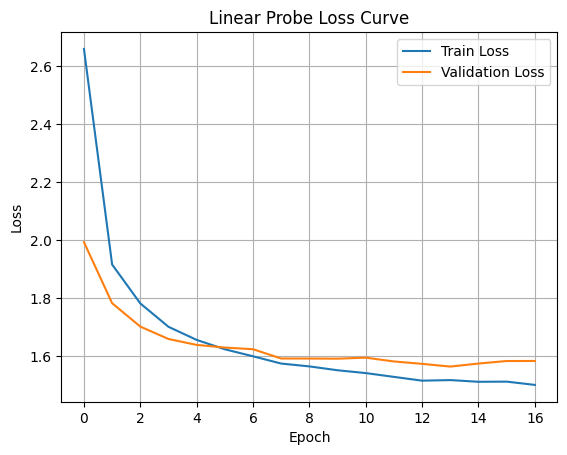

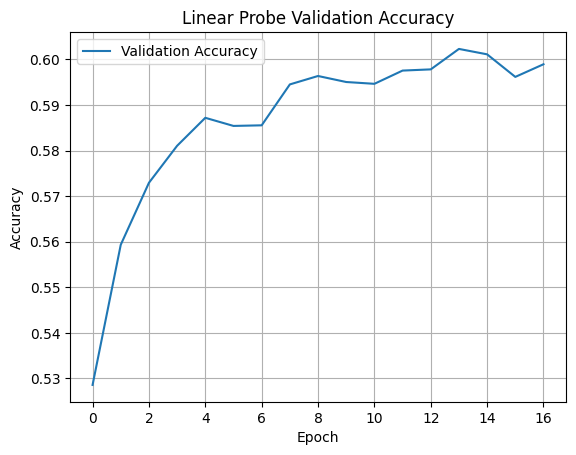

In [21]:
import json
import matplotlib.pyplot as plt

with open("history_linear_efficientnetv2.json", "r") as f:
    history = json.load(f)

plt.figure()
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Linear Probe Loss Curve")
plt.legend()
plt.grid()
plt.savefig("loss_curve_linear_efficientnetv2.png")

plt.figure()
plt.plot(history["val_acc"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Linear Probe Validation Accuracy")
plt.legend()
plt.grid()
plt.savefig("accuracy_curve_linear_efficientnetv2.png")


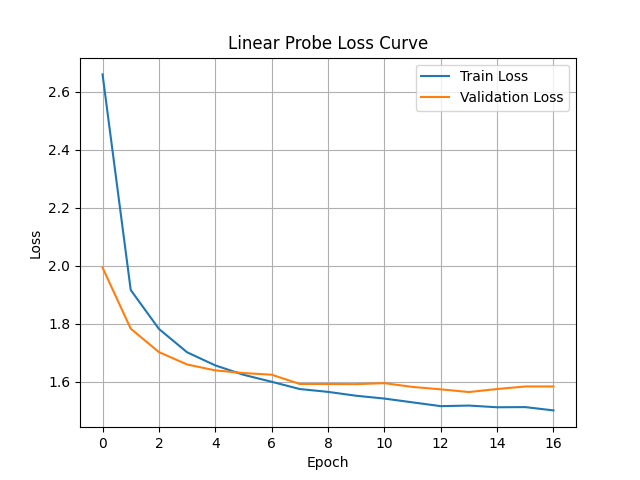

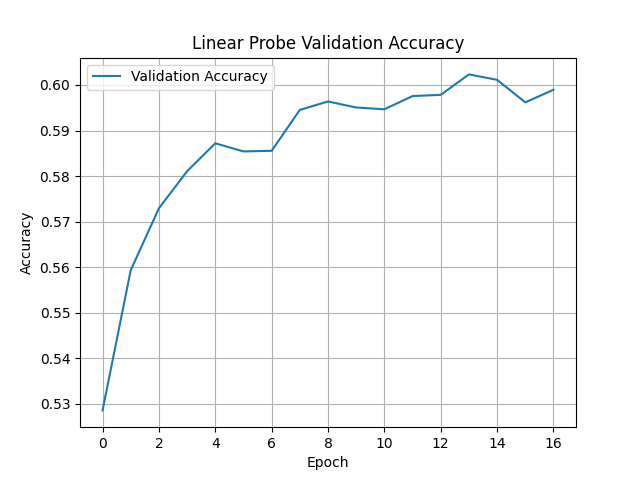

In [22]:
from PIL import Image
from IPython.display import display

display(Image.open("loss_curve_linear_efficientnetv2.png"))
display(Image.open("accuracy_curve_linear_efficientnetv2.png"))


Then we start PEFT by doing BatchNorm tuning for EfficientNetV2-S


In [23]:
if "model" in globals():
    del model
release_memory()

model = build_efficientnetv2_model(num_classes=num_classes)

for param in model.parameters():
    param.requires_grad = False

for p in model.classifier.parameters():
    p.requires_grad = True

for m in model.modules():
    if isinstance(m, nn.BatchNorm2d):
        if m.weight is not None:
            m.weight.requires_grad = True
        if m.bias is not None:
            m.bias.requires_grad = True

model = model.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-3
)

print("Trainable params:", count_trainable_params(model))


Trainable params: 283253


In [24]:
import json

history = train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    device,
    epochs=30,
    patience=3,
    save_path="batch_norm_model_efficientnetv2.pth"
)

with open("history_bn_efficientnetv2.json", "w") as f:
    json.dump(history, f)


/tmp/ipykernel_10120/4244247868.py:38: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=use_amp)


Epoch 1/30 | Train Loss: 1.6476 | Val Loss: 0.9601 | Val Acc: 0.7465 | Time: 352.06s
Best model saved
Epoch 2/30 | Train Loss: 0.9177 | Val Loss: 0.8174 | Val Acc: 0.7828 | Time: 348.72s
Best model saved
Epoch 3/30 | Train Loss: 0.7661 | Val Loss: 0.7659 | Val Acc: 0.7974 | Time: 347.35s
Best model saved
Epoch 4/30 | Train Loss: 0.6788 | Val Loss: 0.7395 | Val Acc: 0.8048 | Time: 346.45s
Best model saved
Epoch 5/30 | Train Loss: 0.6172 | Val Loss: 0.7132 | Val Acc: 0.8126 | Time: 347.11s
Best model saved
Epoch 6/30 | Train Loss: 0.5683 | Val Loss: 0.7048 | Val Acc: 0.8143 | Time: 348.36s
Best model saved
Epoch 7/30 | Train Loss: 0.5283 | Val Loss: 0.7015 | Val Acc: 0.8150 | Time: 347.05s
Best model saved
Epoch 8/30 | Train Loss: 0.4961 | Val Loss: 0.6992 | Val Acc: 0.8181 | Time: 348.68s
Best model saved
Epoch 9/30 | Train Loss: 0.4658 | Val Loss: 0.7026 | Val Acc: 0.8186 | Time: 352.41s
No improvement (1/3)
Epoch 10/30 | Train Loss: 0.4426 | Val Loss: 0.6989 | Val Acc: 0.8215 | Time: 

Plotting again to make sure plateaued


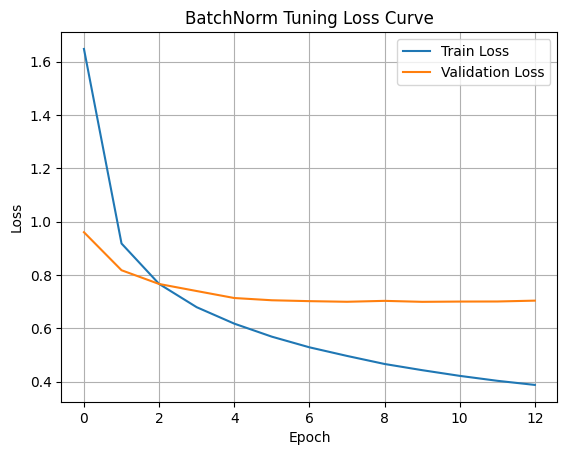

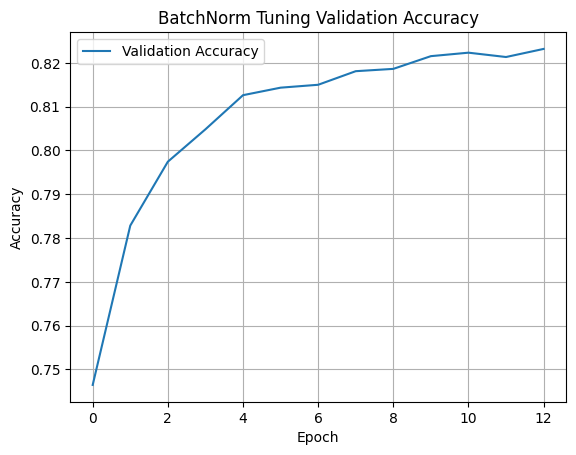

In [25]:
import json
import matplotlib.pyplot as plt

with open("history_bn_efficientnetv2.json", "r") as f:
    history = json.load(f)

plt.figure()
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("BatchNorm Tuning Loss Curve")
plt.legend()
plt.grid()
plt.savefig("loss_curve_bn_efficientnetv2.png")

plt.figure()
plt.plot(history["val_acc"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("BatchNorm Tuning Validation Accuracy")
plt.legend()
plt.grid()
plt.savefig("accuracy_curve_bn_efficientnetv2.png")


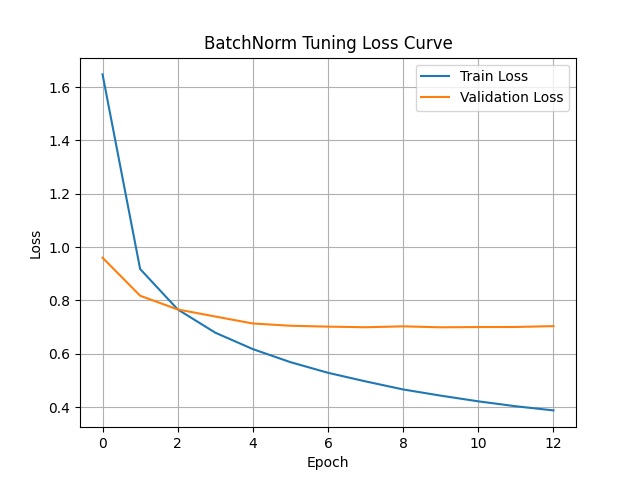

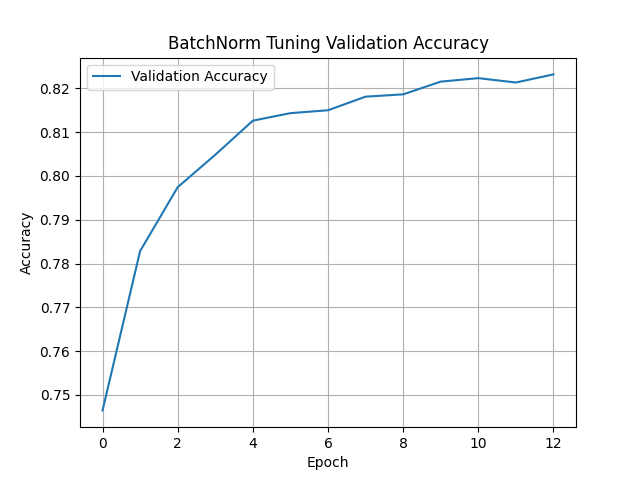

In [26]:
from PIL import Image
from IPython.display import display

display(Image.open("loss_curve_bn_efficientnetv2.png"))
display(Image.open("accuracy_curve_bn_efficientnetv2.png"))


Next should be Task Specific Adapters


In [27]:
if "model" in globals():
    del model
release_memory()

class ConvAdapter(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        hidden = max(channels // reduction, 4)
        self.down = nn.Conv2d(channels, hidden, kernel_size=1, bias=False)
        self.act = nn.ReLU(inplace=True)
        self.up = nn.Conv2d(hidden, channels, kernel_size=1, bias=False)
        nn.init.zeros_(self.up.weight)

    def forward(self, x):
        return x + self.up(self.act(self.down(x)))


class BlockWithAdapter(nn.Module):
    def __init__(self, block, channels, reduction=16):
        super().__init__()
        self.block = block
        self.adapter = ConvAdapter(channels, reduction=reduction)

    def forward(self, x):
        return self.adapter(self.block(x))


def _last_conv_out_channels(module):
    out_channels = None
    for m in module.modules():
        if isinstance(m, nn.Conv2d):
            out_channels = m.out_channels
    return out_channels


def configure_adapter_tuning(model, reduction=16):
    for idx, block in enumerate(model.features):
        channels = _last_conv_out_channels(block)
        if channels is not None:
            model.features[idx] = BlockWithAdapter(block, channels, reduction=reduction)

    for p in model.parameters():
        p.requires_grad = False

    for name, p in model.named_parameters():
        if "adapter." in name or name.startswith("classifier."):
            p.requires_grad = True


model = build_efficientnetv2_model(num_classes=num_classes)
configure_adapter_tuning(model, reduction=16)

model = model.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-3
)

print("Trainable params:", count_trainable_params(model))


Trainable params: 348901


In [28]:
import json

history = train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    device,
    epochs=30,
    patience=3,
    save_path="adapter_model_efficientnetv2.pth"
)

with open("history_adapter_efficientnetv2.json", "w") as f:
    json.dump(history, f)


/tmp/ipykernel_10120/4244247868.py:38: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=use_amp)


Epoch 1/30 | Train Loss: 1.8422 | Val Loss: 2.1658 | Val Acc: 0.6835 | Time: 359.67s
Best model saved
Epoch 2/30 | Train Loss: 1.1937 | Val Loss: 1.2372 | Val Acc: 0.7150 | Time: 361.05s
Best model saved
Epoch 3/30 | Train Loss: 1.0424 | Val Loss: 1.5719 | Val Acc: 0.7311 | Time: 348.02s
No improvement (1/3)
Epoch 4/30 | Train Loss: 0.9469 | Val Loss: 1.5695 | Val Acc: 0.7456 | Time: 348.50s
No improvement (2/3)
Epoch 5/30 | Train Loss: 0.8760 | Val Loss: 1.3713 | Val Acc: 0.7483 | Time: 351.19s
No improvement (3/3)
Early stopping triggered

Total training time: 1768.58s


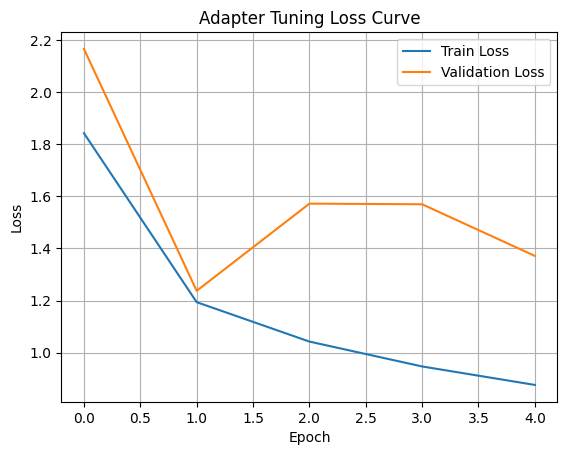

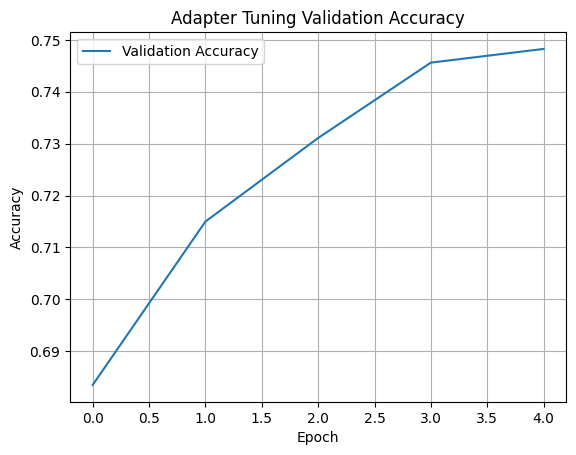

In [29]:
import json
import matplotlib.pyplot as plt

with open("history_adapter_efficientnetv2.json", "r") as f:
    history = json.load(f)

plt.figure()
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Adapter Tuning Loss Curve")
plt.legend()
plt.grid()
plt.savefig("loss_curve_adapter_efficientnetv2.png")

plt.figure()
plt.plot(history["val_acc"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Adapter Tuning Validation Accuracy")
plt.legend()
plt.grid()
plt.savefig("accuracy_curve_adapter_efficientnetv2.png")


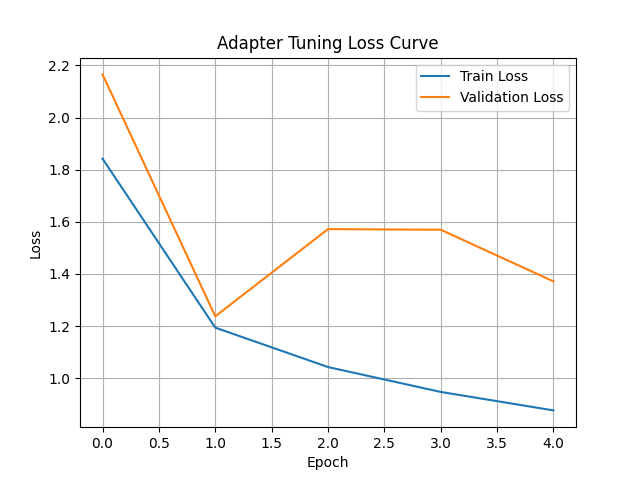

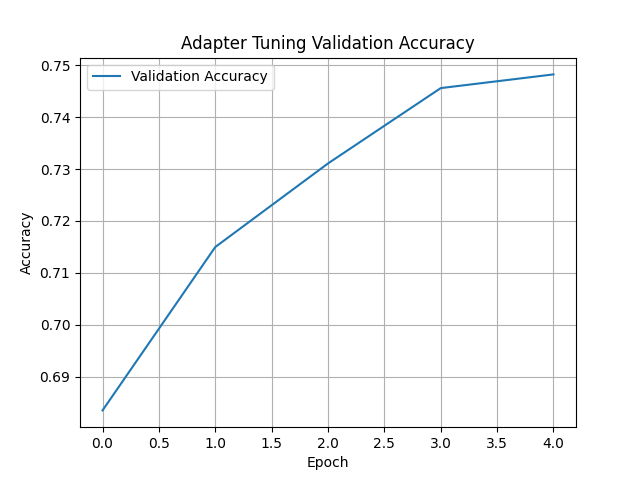

In [30]:
from PIL import Image
from IPython.display import display

display(Image.open("loss_curve_adapter_efficientnetv2.png"))
display(Image.open("accuracy_curve_adapter_efficientnetv2.png"))


Finally, run LoRA tuning as required in the project document


In [31]:
if "model" in globals():
    del model
release_memory()

class LoRAConv2d(nn.Module):
    def __init__(self, conv: nn.Conv2d, rank=4, alpha=8.0):
        super().__init__()
        self.conv = conv
        self.rank = rank
        self.alpha = alpha
        self.scaling = alpha / rank

        for p in self.conv.parameters():
            p.requires_grad = False

        in_features = (conv.in_channels // conv.groups) * conv.kernel_size[0] * conv.kernel_size[1]
        self.lora_A = nn.Parameter(torch.zeros(conv.out_channels, rank))
        self.lora_B = nn.Parameter(torch.zeros(rank, in_features))

        nn.init.kaiming_uniform_(self.lora_B, a=math.sqrt(5))
        nn.init.zeros_(self.lora_A)

    def forward(self, x):
        base = self.conv(x)
        delta_w = (self.lora_A @ self.lora_B).view(
            self.conv.out_channels,
            self.conv.in_channels // self.conv.groups,
            self.conv.kernel_size[0],
            self.conv.kernel_size[1],
        )
        delta = F.conv2d(
            x,
            delta_w * self.scaling,
            bias=None,
            stride=self.conv.stride,
            padding=self.conv.padding,
            dilation=self.conv.dilation,
            groups=self.conv.groups,
        )
        return base + delta


def _inject_lora_conv(module, rank=4, alpha=8.0):
    for name, child in list(module.named_children()):
        if isinstance(child, nn.Conv2d):
            setattr(module, name, LoRAConv2d(child, rank=rank, alpha=alpha))
        else:
            _inject_lora_conv(child, rank=rank, alpha=alpha)


def configure_lora_tuning(model, rank=4, alpha=8.0):
    _inject_lora_conv(model.features, rank=rank, alpha=alpha)

    for p in model.parameters():
        p.requires_grad = False

    for name, p in model.named_parameters():
        if "lora_A" in name or "lora_B" in name or name.startswith("classifier."):
            p.requires_grad = True


model = build_efficientnetv2_model(num_classes=num_classes)
configure_lora_tuning(model, rank=4, alpha=8.0)

model = model.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=2e-3
)

print("Trainable params:", count_trainable_params(model))


Trainable params: 902153


In [32]:
import json

history = train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    device,
    epochs=30,
    patience=3,
    save_path="lora_model_efficientnetv2.pth"
)

with open("history_lora_efficientnetv2.json", "w") as f:
    json.dump(history, f)


/tmp/ipykernel_10120/4244247868.py:38: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=use_amp)


Epoch 1/30 | Train Loss: 1.2962 | Val Loss: 0.9187 | Val Acc: 0.7571 | Time: 422.54s
Best model saved
Epoch 2/30 | Train Loss: 0.8199 | Val Loss: 0.8451 | Val Acc: 0.7772 | Time: 422.79s
Best model saved
Epoch 3/30 | Train Loss: 0.7201 | Val Loss: 0.7780 | Val Acc: 0.7903 | Time: 427.63s
Best model saved
Epoch 4/30 | Train Loss: 0.6609 | Val Loss: 0.9852 | Val Acc: 0.7354 | Time: 425.02s
No improvement (1/3)
Epoch 5/30 | Train Loss: 0.6146 | Val Loss: 0.8131 | Val Acc: 0.7872 | Time: 421.21s
No improvement (2/3)
Epoch 6/30 | Train Loss: 0.5843 | Val Loss: 0.7758 | Val Acc: 0.7980 | Time: 423.45s
Best model saved
Epoch 7/30 | Train Loss: 0.5605 | Val Loss: 0.8833 | Val Acc: 0.7736 | Time: 426.81s
No improvement (1/3)
Epoch 8/30 | Train Loss: 0.5385 | Val Loss: 0.8075 | Val Acc: 0.7919 | Time: 420.38s
No improvement (2/3)
Epoch 9/30 | Train Loss: 0.5208 | Val Loss: 0.7861 | Val Acc: 0.8017 | Time: 422.29s
No improvement (3/3)
Early stopping triggered

Total training time: 3812.47s


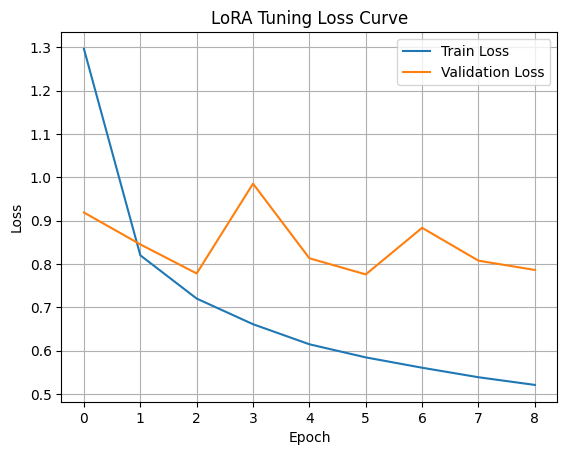

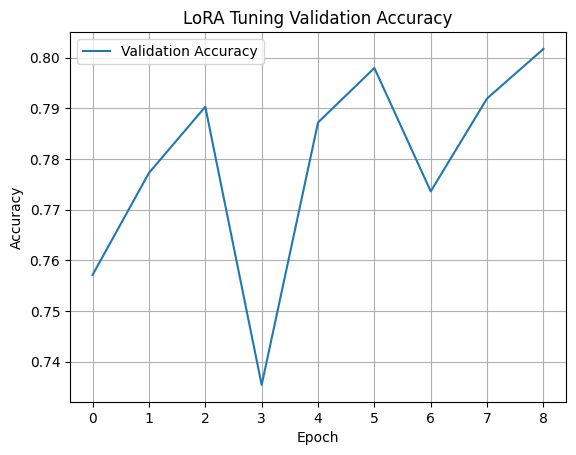

In [33]:
import json
import matplotlib.pyplot as plt

with open("history_lora_efficientnetv2.json", "r") as f:
    history = json.load(f)

plt.figure()
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("LoRA Tuning Loss Curve")
plt.legend()
plt.grid()
plt.savefig("loss_curve_lora_efficientnetv2.png")

plt.figure()
plt.plot(history["val_acc"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("LoRA Tuning Validation Accuracy")
plt.legend()
plt.grid()
plt.savefig("accuracy_curve_lora_efficientnetv2.png")


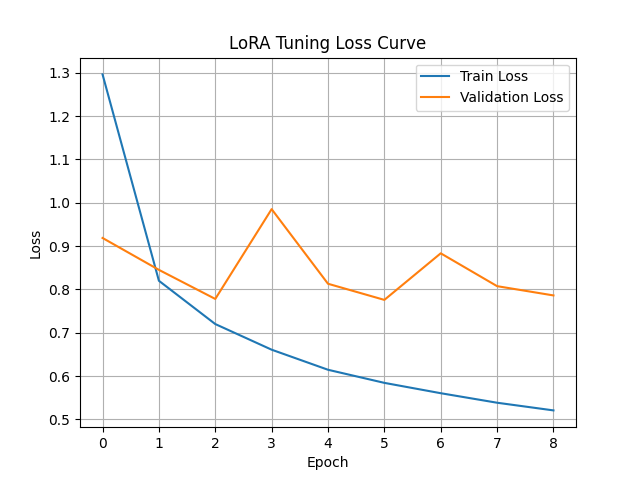

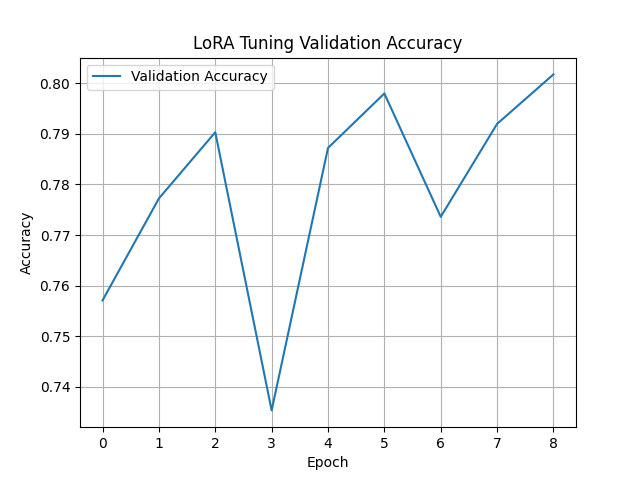

In [34]:
from PIL import Image
from IPython.display import display

display(Image.open("loss_curve_lora_efficientnetv2.png"))
display(Image.open("accuracy_curve_lora_efficientnetv2.png"))


Full Tuning

In [19]:
if "model" in globals():
    del model
release_memory()

model = build_efficientnetv2_model(num_classes=num_classes)

for param in model.parameters():
    param.requires_grad = True

model = model.to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

print("Trainable params:", count_trainable_params(model))

Trainable params: 20306869


In [21]:
import json

history = train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    device,
    epochs=30,
    patience=2,
    save_path="full_model_efficientnetv2.pth"
)

#Task manager says 15.7gb vram

with open("history_full_efficientnetv2.json", "w") as f:
    json.dump(history, f)

C:\Users\yueya\AppData\Local\Temp\ipykernel_41624\4244247868.py:38: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=use_amp)


Epoch 1/30 | Train Loss: 1.6210 | Val Loss: 0.7470 | Val Acc: 0.8038 | Time: 688.27s
Best model saved
Epoch 2/30 | Train Loss: 0.5695 | Val Loss: 0.6224 | Val Acc: 0.8374 | Time: 656.05s
Best model saved
Epoch 3/30 | Train Loss: 0.3277 | Val Loss: 0.6213 | Val Acc: 0.8413 | Time: 656.91s
Best model saved
Epoch 4/30 | Train Loss: 0.2059 | Val Loss: 0.6625 | Val Acc: 0.8370 | Time: 652.68s
No improvement (1/2)
Epoch 5/30 | Train Loss: 0.1401 | Val Loss: 0.7063 | Val Acc: 0.8328 | Time: 649.66s
No improvement (2/2)
Early stopping triggered

Total training time: 3303.96s


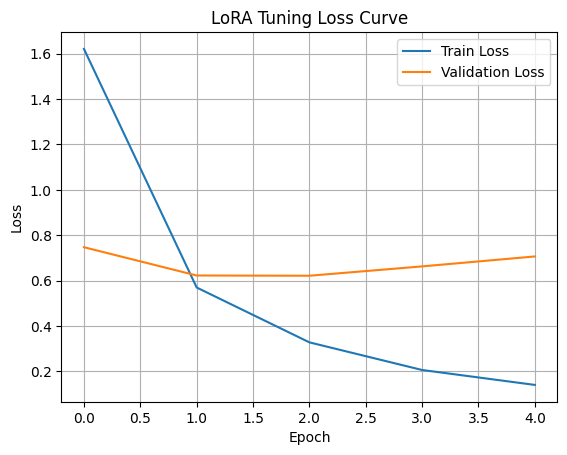

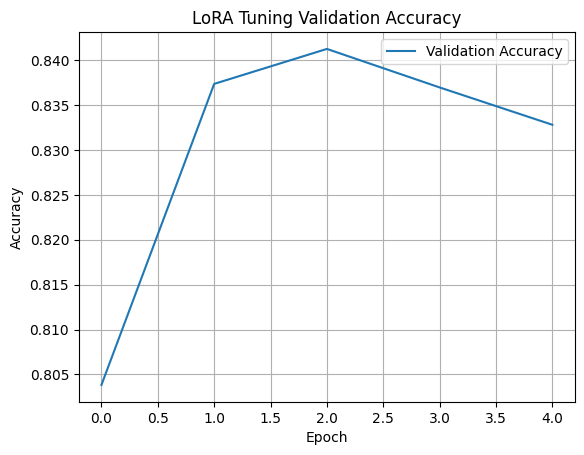

In [1]:
import json
import matplotlib.pyplot as plt

with open("history_full_efficientnetv2.json", "r") as f:
    history = json.load(f)

plt.figure()
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("LoRA Tuning Loss Curve")
plt.legend()
plt.grid()
plt.savefig("loss_curve_full_efficientnetv2.png")

plt.figure()
plt.plot(history["val_acc"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("LoRA Tuning Validation Accuracy")
plt.legend()
plt.grid()
plt.savefig("accuracy_curve_full_efficientnetv2.png")


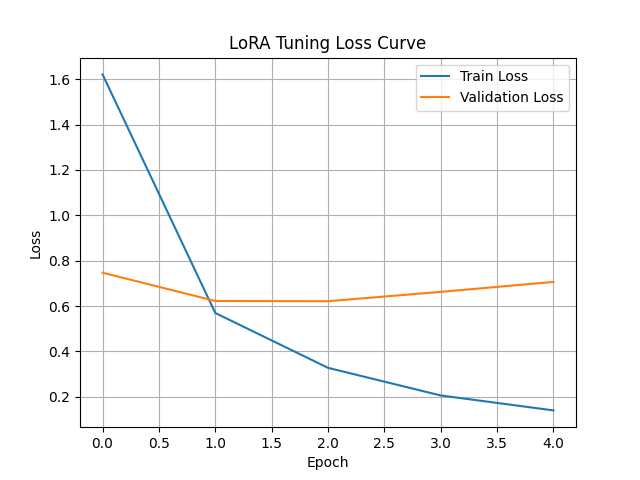

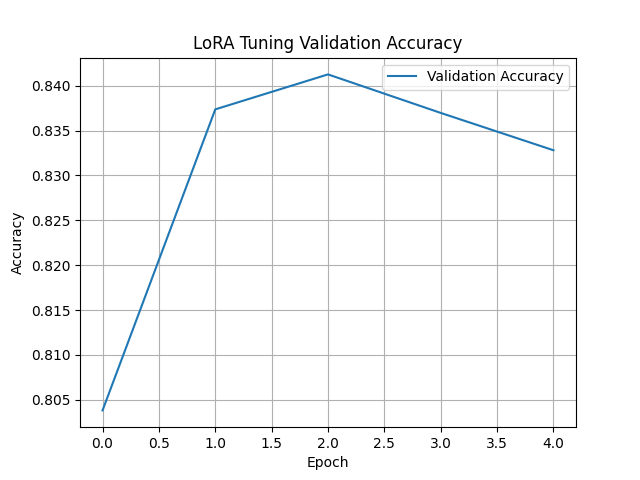

In [2]:
from PIL import Image
from IPython.display import display

display(Image.open("loss_curve_full_efficientnetv2.png"))
display(Image.open("accuracy_curve_full_efficientnetv2.png"))

Evaluate all trained models on clean test set and transformed test variants from Google Drive


In [35]:
import json
import tarfile
import zipfile
from pathlib import Path

import pandas as pd
from torchvision import datasets


class ImageFolderRemapped(Dataset):
    def __init__(self, root, transform, class_to_idx_ref):
        self.base = datasets.ImageFolder(str(root), transform=transform)
        self.index_map = {}

        missing = []
        for class_name, base_idx in self.base.class_to_idx.items():
            if class_name not in class_to_idx_ref:
                missing.append(class_name)
                continue
            self.index_map[base_idx] = class_to_idx_ref[class_name]

        if missing:
            sample_missing = ", ".join(sorted(missing)[:5])
            raise ValueError(f"Unknown class folders in variant set {root}: {sample_missing}")

    def __len__(self):
        return len(self.base)

    def __getitem__(self, idx):
        image, label = self.base[idx]
        return image, self.index_map[label]


def evaluate_metrics(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_seen = 0

    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)
            labels = labels.to(device)

            outputs = model(imgs)
            loss = criterion(outputs, labels)

            total_loss += loss.item() * labels.size(0)
            total_correct += (outputs.argmax(dim=1) == labels).sum().item()
            total_seen += labels.size(0)

    return {
        "loss": total_loss / max(total_seen, 1),
        "acc": total_correct / max(total_seen, 1),
    }


def maybe_download_variant_archive(output_dir, file_id, archive_name):
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    archive_path = output_dir / archive_name

    if archive_path.exists():
        print("Using existing archive:", archive_path)
        return archive_path

    try:
        import gdown
    except ImportError as exc:
        raise RuntimeError(
            "gdown is required for Google Drive download. Install with: pip install gdown"
        ) from exc

    print("Downloading transformed test variants from Google Drive...")
    gdown.download(id=file_id, output=str(archive_path), quiet=False, fuzzy=True)

    if not archive_path.exists():
        raise RuntimeError("Download failed: archive not found after gdown download.")

    return archive_path


def extract_archive(archive_path, output_dir):
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    suffixes = [s.lower() for s in archive_path.suffixes]
    if archive_path.suffix.lower() == ".zip":
        with zipfile.ZipFile(archive_path, "r") as zf:
            zf.extractall(output_dir)
    elif ".tar" in suffixes or suffixes[-2:] in [[".tar", ".gz"], [".tar", ".bz2"], [".tar", ".xz"]]:
        with tarfile.open(archive_path, "r:*") as tf:
            tf.extractall(output_dir)
    else:
        raise ValueError(f"Unsupported archive type: {archive_path}")

    return output_dir


def _contains_class_folders(path):
    if not path.is_dir():
        return False

    class_dirs = [d for d in path.iterdir() if d.is_dir()]
    if not class_dirs:
        return False

    image_extensions = {".jpg", ".jpeg", ".png", ".webp"}
    image_count = 0
    for class_dir in class_dirs[:8]:
        for file in class_dir.iterdir():
            if file.is_file() and file.suffix.lower() in image_extensions:
                image_count += 1
                break

    return image_count >= max(1, min(3, len(class_dirs)))


def discover_variant_sets(root):
    root = Path(root)
    variants = {}

    if not root.exists():
        return variants

    if _contains_class_folders(root):
        variants[root.name] = root
        return variants

    for child in sorted(root.iterdir()):
        if child.is_dir() and _contains_class_folders(child):
            variants[child.name] = child

    if variants:
        return variants

    for child in sorted(root.iterdir()):
        if not child.is_dir():
            continue
        for grandchild in sorted(child.iterdir()):
            if grandchild.is_dir() and _contains_class_folders(grandchild):
                variants[grandchild.name] = grandchild

    return variants


# Google Drive transformed test variants provided in project document
USE_GOOGLEDRIVE_VARIANTS = True
GOOGLEDRIVE_FILE_ID = "1MvkUSd2ESqBzXgObUYBBxOH6kMFLDP5B"
VARIANT_ARCHIVE_NAME = "food101_test_variants.zip"
VARIANT_DOWNLOAD_DIR = Path.cwd() / "food101_transformed_test_variants"

# Set this if you already downloaded/extracted somewhere else
MANUAL_VARIANT_ROOT = None

variant_loaders = {}

if USE_GOOGLEDRIVE_VARIANTS:
    archive_path = maybe_download_variant_archive(
        output_dir=VARIANT_DOWNLOAD_DIR,
        file_id=GOOGLEDRIVE_FILE_ID,
        archive_name=VARIANT_ARCHIVE_NAME,
    )

    extracted_root = VARIANT_DOWNLOAD_DIR / "extracted"
    if not extracted_root.exists() or not any(extracted_root.iterdir()):
        print("Extracting transformed test variants...")
        extract_archive(archive_path, extracted_root)
    else:
        print("Using existing extracted folder:", extracted_root)

    variant_sets = discover_variant_sets(extracted_root)
else:
    variant_sets = {}
    if MANUAL_VARIANT_ROOT is not None:
        variant_sets = discover_variant_sets(Path(MANUAL_VARIANT_ROOT).expanduser().resolve())

print("Variant sets discovered:", sorted(variant_sets.keys()))

for variant_name, variant_dir in variant_sets.items():
    variant_dataset = ImageFolderRemapped(
        variant_dir,
        transform=transform,
        class_to_idx_ref=full_train_dataset.class_to_idx,
    )
    variant_loaders[variant_name] = DataLoader(
        variant_dataset,
        batch_size=64,
        shuffle=False,
        num_workers=0,
        pin_memory=(device.type == "cuda"),
    )


def load_history(name):
    with open(name, "r") as f:
        return json.load(f)


strategy_configs = [
    {
        "name": "linear_probe",
        "weights": "best_linear_model_efficientnetv2.pth",
        "history": "history_linear_efficientnetv2.json",
        "setup": lambda m: m,
    },
    {
        "name": "batchnorm_tuning",
        "weights": "batch_norm_model_efficientnetv2.pth",
        "history": "history_bn_efficientnetv2.json",
        "setup": lambda m: m,
    },
    {
        "name": "adapter_tuning",
        "weights": "adapter_model_efficientnetv2.pth",
        "history": "history_adapter_efficientnetv2.json",
        "setup": lambda m: configure_adapter_tuning(m, reduction=16),
    },
    {
        "name": "lora_tuning",
        "weights": "lora_model_efficientnetv2.pth",
        "history": "history_lora_efficientnetv2.json",
        "setup": lambda m: configure_lora_tuning(m, rank=4, alpha=8.0),
    },
]

criterion = nn.CrossEntropyLoss()
results = []

for cfg in strategy_configs:
    if "eval_model" in globals():
        del eval_model
    release_memory()
    eval_model = build_efficientnetv2_model(num_classes=num_classes)
    cfg["setup"](eval_model)
    eval_model.load_state_dict(torch.load(cfg["weights"], map_location=device))
    eval_model = eval_model.to(device)

    clean_metrics = evaluate_metrics(eval_model, test_loader, criterion)
    hist = load_history(cfg["history"])

    row = {
        "strategy": cfg["name"],
        "clean_test_acc": clean_metrics["acc"],
        "clean_test_loss": clean_metrics["loss"],
        "trainable_params": hist.get("trainable_params"),
        "train_seconds": hist.get("total_time"),
        "best_val_acc": max(hist["val_acc"]) if hist.get("val_acc") else None,
    }

    for variant_name, v_loader in variant_loaders.items():
        v_metrics = evaluate_metrics(eval_model, v_loader, criterion)
        row[f"variant_{variant_name}_acc"] = v_metrics["acc"]
        row[f"variant_{variant_name}_loss"] = v_metrics["loss"]

    results.append(row)

results_df = pd.DataFrame(results).sort_values("clean_test_acc", ascending=False)
results_df.to_csv("efficientnetv2_results_try2.csv", index=False)
results_df


Downloading...
From (original): https://drive.google.com/uc?id=1MvkUSd2ESqBzXgObUYBBxOH6kMFLDP5B
From (redirected): https://drive.google.com/uc?id=1MvkUSd2ESqBzXgObUYBBxOH6kMFLDP5B&confirm=t&uuid=0ad0f348-7ab2-458a-bbf2-9907e446b557
To: /content/food101_transformed_test_variants/food101_test_variants.zip
100%|██████████| 4.37G/4.37G [01:27<00:00, 50.1MB/s]


Extracting transformed test variants...
Variant sets discovered: ['blur_little', 'blur_medium', 'clean', 'downsampled', 'masked', 'noise_rotation']


,strategy,clean_test_acc,clean_test_loss,trainable_params,train_seconds,best_val_acc,variant_blur_little_acc,variant_blur_little_loss,variant_blur_medium_acc,variant_blur_medium_loss,variant_clean_acc,variant_clean_loss,variant_downsampled_acc,variant_downsampled_loss,variant_masked_acc,variant_masked_loss,variant_noise_rotation_acc,variant_noise_rotation_loss
1,batchnorm_tuning,0.862099,0.481698,283253,4542.646356,0.823168,0.778733,0.808341,0.593901,1.608468,0.854020,0.512370,0.273941,3.730265,0.848000,0.534148,0.806931,0.690686
3,lora_tuning,0.841386,0.556213,902153,3812.468396,0.801716,0.747406,0.910311,0.555960,1.753219,0.829584,0.601226,0.262020,3.437535,0.820832,0.631296,0.768673,0.825799
2,adapter_tuning,0.761743,0.850954,348901,1768.577542,0.748251,0.637069,1.352443,0.407604,2.379842,0.749624,0.895768,0.164198,4.037191,0.741069,0.931231,0.682693,1.151849
0,linear_probe,0.646772,1.324890,129381,5473.958655,0.602310,0.483168,2.081947,0.279089,3.104169,0.633347,1.394375,0.087168,4.917770,0.622297,1.440070,0.564911,1.697061


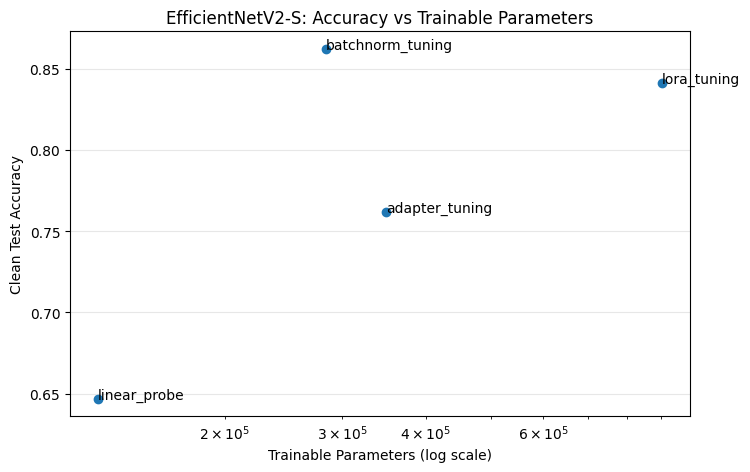

In [36]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.scatter(results_df["trainable_params"], results_df["clean_test_acc"])
for _, row in results_df.iterrows():
    plt.annotate(row["strategy"], (row["trainable_params"], row["clean_test_acc"]))
plt.xscale("log")
plt.xlabel("Trainable Parameters (log scale)")
plt.ylabel("Clean Test Accuracy")
plt.title("EfficientNetV2-S: Accuracy vs Trainable Parameters")
plt.grid(True, alpha=0.3)
plt.show()
